In [1]:
# Impor modul yang diperlukan dan atur path untuk mengakses global_function.py dari folder induk
import sys
import os
import pandas as pd

if '__file__' in globals():
    current_dir = os.path.dirname(os.path.abspath(__file__))
else:
    current_dir = os.getcwd()

parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from global_function import iterative_processor

In [2]:
# Isi rentang data yang ingin diproses dengan metode PCHIP
from global_function import pchip_imputer

# --- 3. DEFINISI KOLOM ---
# List kolom tetap sama karena kita masih menargetkan sensor yang sama
cyl_cols     = [f'Exh Cyl #{i} Temp' for i in range(1, 7)]
support_cols = ['Exh Right Temp', 'Exh Left Temp', 'Oil Temp', 'JW Temp']
all_sensors  = cyl_cols + support_cols

# --- 4. EKSEKUSI ---
data_dir   = r"../Data RTF Mentah"
output_dir = r"Imputed Data"

if __name__ == "__main__":
    # Menjalankan proses iteratif menggunakan metode PCHIP
    processed_files = iterative_processor(
        file_list      = [f'run_to_failure{i}.csv' for i in range(1, 8)],
        operation_func = pchip_imputer,  # Fungsi baru yang lebih simpel dan stabil
        input_dir      = data_dir,
        output_dir     = output_dir,
        columns        = all_sensors
    )
    
    print("\nProses penambalan data dengan metode PCHIP selesai.")


--- Processing: run_to_failure1.csv ---
Sensor Exh Cyl #1 Temp           | Status: Imputed (NaN:  130) | Method: PCHIP Internal
Sensor Exh Cyl #2 Temp           | Status: Imputed (NaN:  130) | Method: PCHIP Internal
Sensor Exh Cyl #3 Temp           | Status: Imputed (NaN:  130) | Method: PCHIP Internal
Sensor Exh Cyl #4 Temp           | Status: Imputed (NaN:  130) | Method: PCHIP Internal
Sensor Exh Cyl #5 Temp           | Status: Imputed (NaN:  130) | Method: PCHIP Internal
Sensor Exh Cyl #6 Temp           | Status: Imputed (NaN:  130) | Method: PCHIP Internal
Sensor Exh Right Temp            | Status: Imputed (NaN:  130) | Method: PCHIP Internal
Sensor Exh Left Temp             | Status: Imputed (NaN:  130) | Method: PCHIP Internal
Sensor Oil Temp                  | Status: Imputed (NaN:  130) | Method: PCHIP Internal
Sensor JW Temp                   | Status: Imputed (NaN:  130) | Method: PCHIP Internal

--- Processing: run_to_failure2.csv ---
Sensor Exh Cyl #1 Temp           | Sta

In [3]:
# Bersihkan data dari outlier menggunakan metode IQR
from global_function import outlier_cleaner_pchip

# --- CONFIGURATION ---
data_dir   = r"../Preprocess/Imputed Data"
output_dir = r"Clean Data"
cyl_cols   = [f'Exh Cyl #{i} Temp' for i in range(1, 7)]
support_cols = ['Exh Right Temp', 'Exh Left Temp', 'Oil Temp', 'JW Temp']
all_sensors = cyl_cols + support_cols

if __name__ == "__main__":
    processed_files = iterative_processor(
        file_list      = [f'run_to_failure{i}.csv' for i in range(1, 8)],
        operation_func = outlier_cleaner_pchip,
        input_dir      = data_dir,
        output_dir     = output_dir,
        columns        = all_sensors,
        protection_percent = 0.20  # Parameter tambahan untuk melindungi 20% data terakhir
    )
    
    print("\nOutlier removal dan pembersihan data selesai.")


--- Processing: run_to_failure1.csv ---
Sensor Exh Cyl #1 Temp           | Status: Outlier Removed (   2) | Method: IQR + PCHIP
Sensor Exh Cyl #2 Temp           | Status: Clean (No Outliers)    | Method: -
Sensor Exh Cyl #3 Temp           | Status: Outlier Removed (   8) | Method: IQR + PCHIP
Sensor Exh Cyl #4 Temp           | Status: Clean (No Outliers)    | Method: -
Sensor Exh Cyl #5 Temp           | Status: Clean (No Outliers)    | Method: -
Sensor Exh Cyl #6 Temp           | Status: Clean (No Outliers)    | Method: -
Sensor Exh Right Temp            | Status: Outlier Removed (   4) | Method: IQR + PCHIP
Sensor Exh Left Temp             | Status: Clean (No Outliers)    | Method: -
Sensor Oil Temp                  | Status: Clean (No Outliers)    | Method: -
Sensor JW Temp                   | Status: Clean (No Outliers)    | Method: -

--- Processing: run_to_failure2.csv ---
Sensor Exh Cyl #1 Temp           | Status: Clean (No Outliers)    | Method: -
Sensor Exh Cyl #2 Temp        

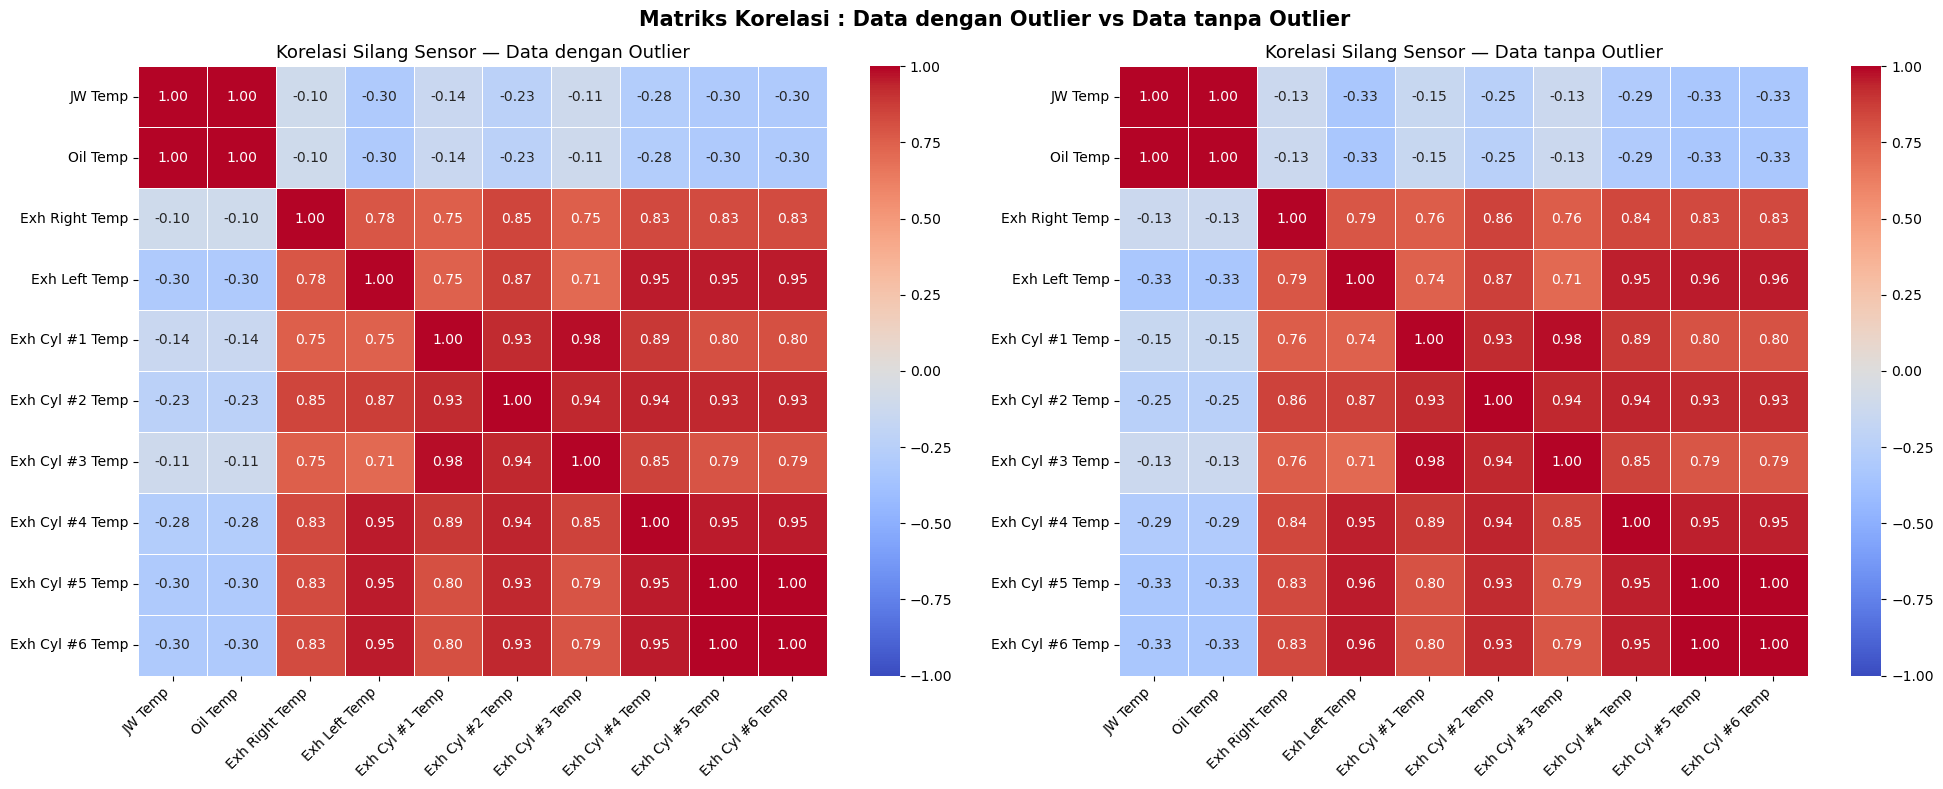

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

DIRTY_DIR = "Imputed Data"
CLEAN_DIR = "Clean Data"
RUN_COUNT = 7

def load_and_combine(directory):
    dfs = []
    for i in range(1, RUN_COUNT + 1):
        path = os.path.join(directory, f'run_to_failure{i}.csv')
        if not os.path.exists(path):
            print(f"Skip: {path}")
            continue
        dfs.append(pd.read_csv(path))
    if not dfs:
        raise FileNotFoundError(f"Tidak ada file CSV di {directory}")
    return pd.concat(dfs, ignore_index=True)

dirty_data = load_and_combine(DIRTY_DIR).select_dtypes(include=["number"])
clean_data = load_and_combine(CLEAN_DIR).select_dtypes(include=["number"])

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, data, title in zip(axes,
                            [dirty_data, clean_data],
                            ["Data dengan Outlier", "Data tanpa Outlier"]):
    corr = data.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, vmin=-1, vmax=1,
                linewidths=0.5, ax=ax)
    ax.set_title(f"Korelasi Silang Sensor — {title}", fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle("Matriks Korelasi : Data dengan Outlier vs Data tanpa Outlier", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()